In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import glob
import pyproj
import math

# visualisations
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

In [2]:
%store -r gnss_df

In [3]:
%store -r gt_df

In [4]:
# 1. Setup the Transformer
# EPSG:4326 is standard Lat/Lon (WGS84)
# EPSG:4978 is standard ECEF (WGS84)
transformer = pyproj.Transformer.from_crs("epsg:4326", "epsg:4978", always_xy=True)

def get_ecef(df_gt):
    x, y, z = transformer.transform(
        df_gt['LongitudeDegrees'].values, 
        df_gt['LatitudeDegrees'].values, 
        df_gt['AltitudeMeters'].values
    )
    
    df_gt['GroundTruthXEcefMeters'] = x
    df_gt['GroundTruthYEcefMeters'] = y
    df_gt['GroundTruthZEcefMeters'] = z
    return df_gt

def get_wls_val(df_gt, df_gnss):
    gnss_grp_df = df_gnss.groupby(
        ['utcTimeMillis', 'drive_id', 'device'],
        as_index=False
    )[[
        'WlsPositionXEcefMeters',
        'WlsPositionYEcefMeters',
        'WlsPositionZEcefMeters'
    ]].first()
    
    gnss_renamed_df = gnss_grp_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})

    df_merge = df_gt.merge(gnss_renamed_df[['UnixTimeMillis', 'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
    
    return df_merge 

def get_target_var(df_gt):
    df_gt['ErrorXEcefMeters'] = df_gt['GroundTruthXEcefMeters'] - df_gt['WlsPositionXEcefMeters']
    df_gt['ErrorYEcefMeters'] = df_gt['GroundTruthYEcefMeters'] - df_gt['WlsPositionYEcefMeters']
    df_gt['ErrorZEcefMeters'] = df_gt['GroundTruthZEcefMeters'] - df_gt['WlsPositionZEcefMeters']
    
    return df_gt


# convert lat/lon to ecef
gt_df = get_ecef(gt_df)

# clone df
target_df = gt_df.copy()

# get wls_val 
target_df = get_wls_val(target_df, gnss_df)

# get x, y, z error
target_df = get_target_var(target_df)

print(target_df.head())

   UnixTimeMillis        device             drive_id  LatitudeDegrees  \
0   1609800004433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   
1   1609800005433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   
2   1609800006433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   
3   1609800007433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   
4   1609800008433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   

   LongitudeDegrees  AltitudeMeters  GroundTruthXEcefMeters  \
0       -122.232673          11.581           -2.704219e+06   
1       -122.232673          11.581           -2.704219e+06   
2       -122.232673          11.582           -2.704219e+06   
3       -122.232673          11.582           -2.704219e+06   
4       -122.232673          11.582           -2.704219e+06   

   GroundTruthYEcefMeters  GroundTruthZEcefMeters  WlsPositionXEcefMeters  \
0           -4.288801e+06            3.856672e+06           -2.704222e+06   
1           -4.288801e+06   

In [5]:
print(target_df.isna().sum())

UnixTimeMillis                 0
device                         0
drive_id                       0
LatitudeDegrees                0
LongitudeDegrees               0
AltitudeMeters            129583
GroundTruthXEcefMeters    129583
GroundTruthYEcefMeters    129583
GroundTruthZEcefMeters    129583
WlsPositionXEcefMeters        33
WlsPositionYEcefMeters        33
WlsPositionZEcefMeters        33
ErrorXEcefMeters          129589
ErrorYEcefMeters          129589
ErrorZEcefMeters          129589
dtype: int64


In [6]:
target_df = target_df.dropna(subset=['WlsPositionXEcefMeters'])
target_df = target_df.dropna(subset=['WlsPositionYEcefMeters'])
target_df = target_df.dropna(subset=['WlsPositionZEcefMeters'])

print(target_df.isna().sum())

UnixTimeMillis                 0
device                         0
drive_id                       0
LatitudeDegrees                0
LongitudeDegrees               0
AltitudeMeters            129556
GroundTruthXEcefMeters    129556
GroundTruthYEcefMeters    129556
GroundTruthZEcefMeters    129556
WlsPositionXEcefMeters         0
WlsPositionYEcefMeters         0
WlsPositionZEcefMeters         0
ErrorXEcefMeters          129556
ErrorYEcefMeters          129556
ErrorZEcefMeters          129556
dtype: int64


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_21212/3768743151.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(errorxecefmeters_eda_uni, kde = True, color = "b", ax = axes[1]) # distplot for ErrorXEcefMeters


<Axes: >

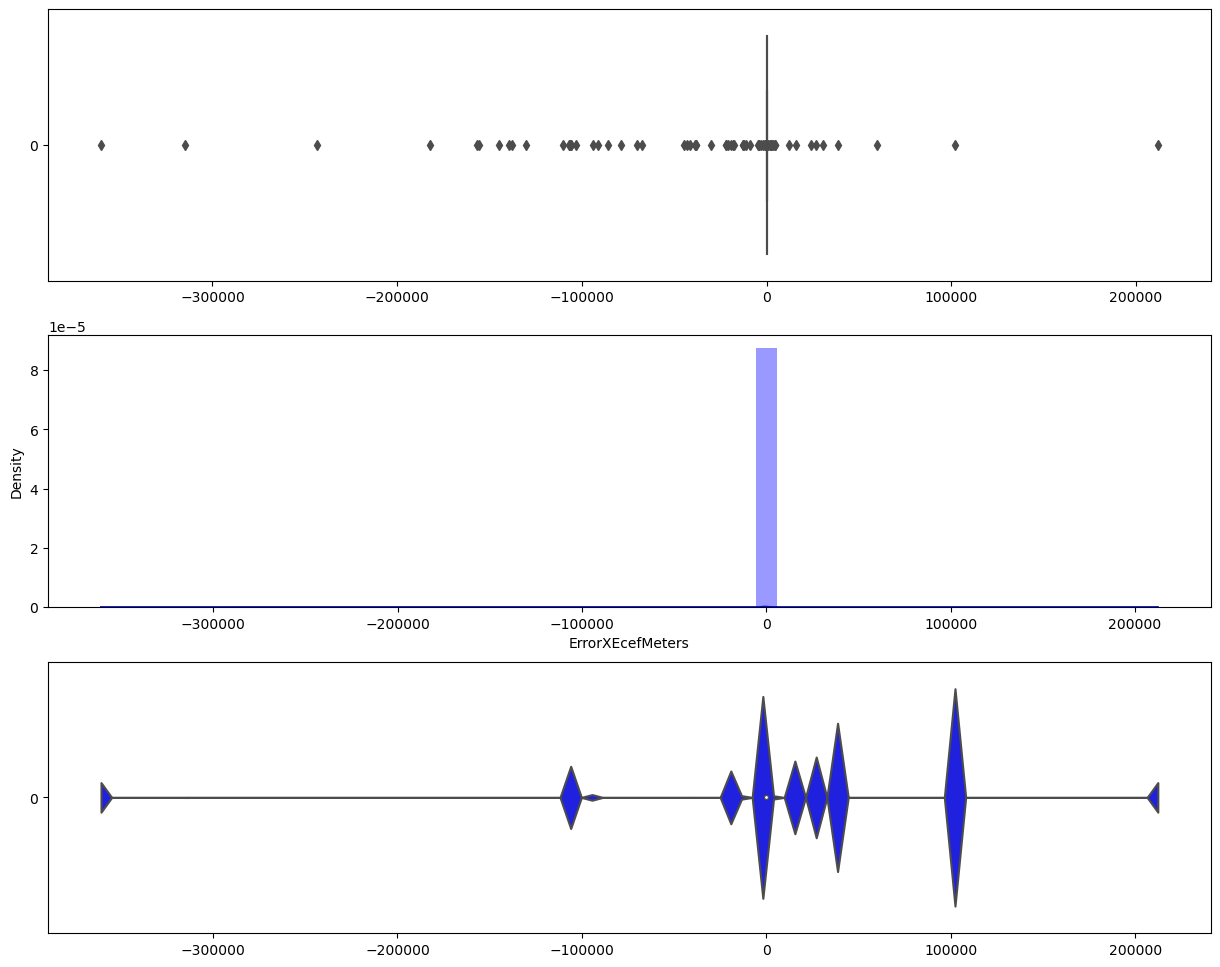

In [7]:
f, axes = plt.subplots(3, 1, figsize=(15,12))

# uni-variate visualisation for errorxecefmeters eda

errorxecefmeters_eda_uni = target_df["ErrorXEcefMeters"]
sb.boxplot(errorxecefmeters_eda_uni, orient = "h", color = "b", ax = axes[0]) # boxplot for ErrorXEcefMeters
sb.distplot(errorxecefmeters_eda_uni, kde = True, color = "b", ax = axes[1]) # distplot for ErrorXEcefMeters
sb.violinplot(errorxecefmeters_eda_uni, orient = "h", color = "b", ax = axes[2]) # violinplot for ErrorXEcefMeters

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_21212/3381124806.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(erroryecefmeters_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for ErrorXEcefMeters


<Axes: >

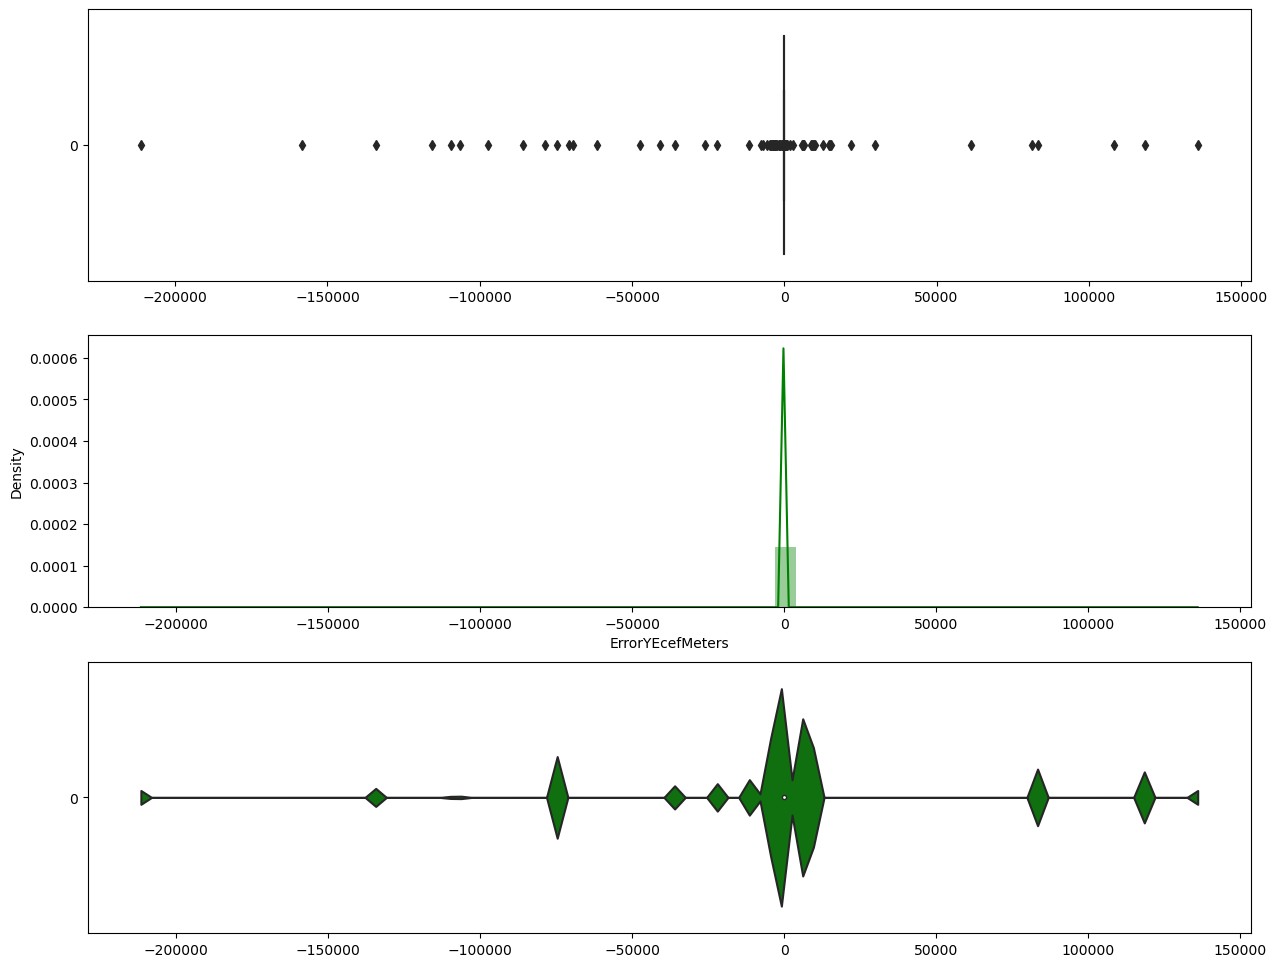

In [8]:
f, axes = plt.subplots(3, 1, figsize=(15,12))

# uni-variate visualisation for erroryecefmeters eda

erroryecefmeters_eda_uni = target_df["ErrorYEcefMeters"]
sb.boxplot(erroryecefmeters_eda_uni, orient = "h", color = "g", ax = axes[0]) # boxplot for ErrorXEcefMeters
sb.distplot(erroryecefmeters_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for ErrorXEcefMeters
sb.violinplot(erroryecefmeters_eda_uni, orient = "h", color = "g", ax = axes[2]) # violinplot for ErrorXEcefMeters

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_21212/661506627.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(errorzecefmeters_eda_uni, kde = True, color = "r", ax = axes[1]) # distplot for ErrorXEcefMeters


<Axes: >

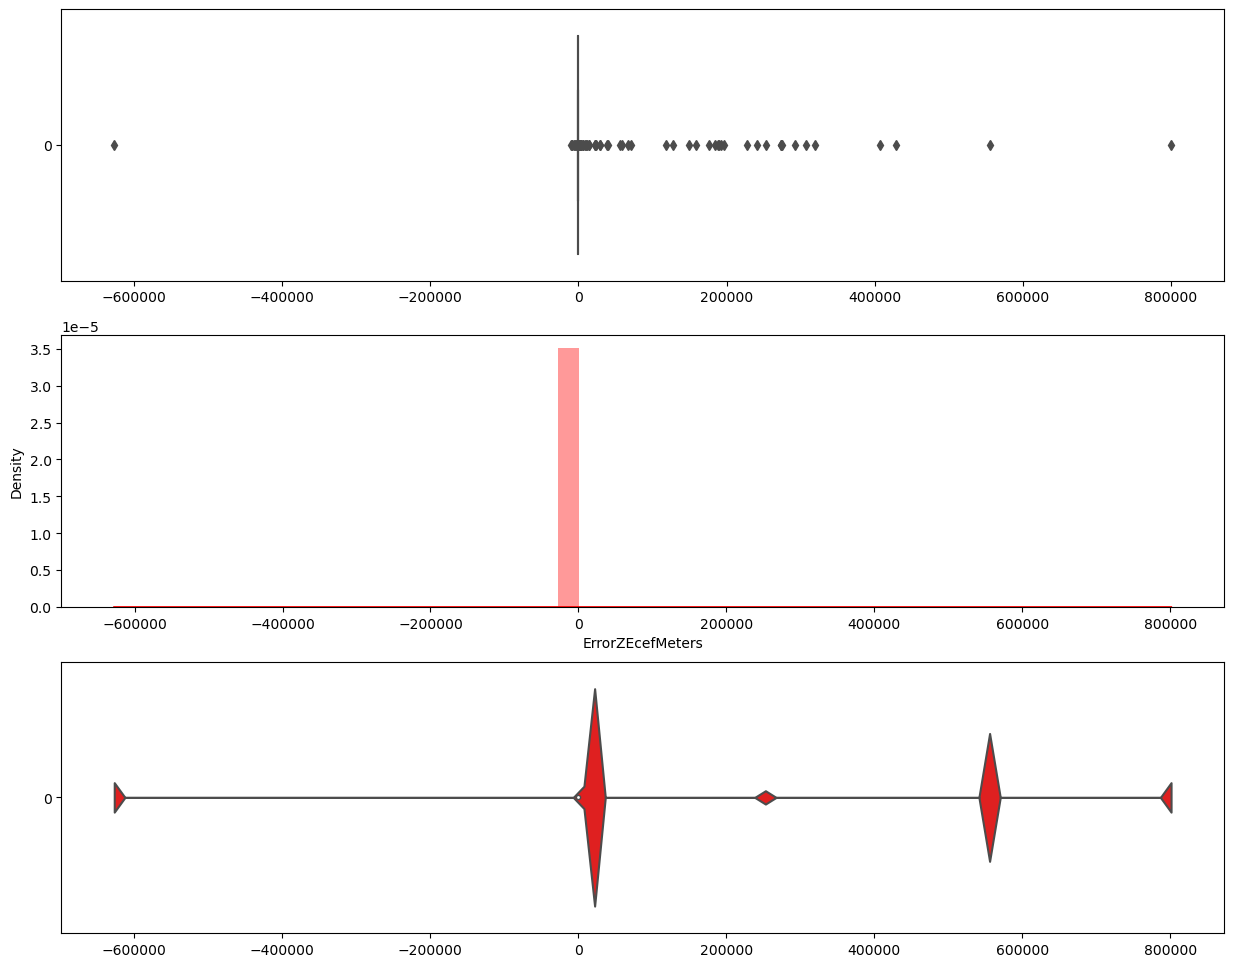

In [9]:
f, axes = plt.subplots(3, 1, figsize=(15,12))

# uni-variate visualisation for errorzecefmeters eda

errorzecefmeters_eda_uni = target_df["ErrorZEcefMeters"]
sb.boxplot(errorzecefmeters_eda_uni, orient = "h", color = "r", ax = axes[0]) # boxplot for ErrorXEcefMeters
sb.distplot(errorzecefmeters_eda_uni, kde = True, color = "r", ax = axes[1]) # distplot for ErrorXEcefMeters
sb.violinplot(errorzecefmeters_eda_uni, orient = "h", color = "r", ax = axes[2]) # violinplot for ErrorXEcefMeters

In [10]:
output_x = target_df['ErrorXEcefMeters']
output_y = target_df['ErrorYEcefMeters']
output_z = target_df['ErrorZEcefMeters']

Q1x = output_x.quantile(0.25)
Q3x = output_x.quantile(0.75)
IQRx = Q3x - Q1x

Q1y = output_y.quantile(0.25)
Q3y = output_y.quantile(0.75)
IQRy = Q3y - Q1y

Q1z = output_z.quantile(0.25)
Q3z = output_z.quantile(0.75)
IQRz = Q3z - Q1z

lower_boundx = Q1x - 1.5 * IQRx
upper_boundx = Q3x + 1.5 * IQRx

lower_boundy = Q1y - 1.5 * IQRy
upper_boundy = Q3y + 1.5 * IQRy

lower_boundz = Q1z - 1.5 * IQRz
upper_boundz = Q3z + 1.5 * IQRz

target_clean_df = target_df[(output_x >= lower_boundx) & (output_x <= upper_boundx)]
target_clean_df = target_clean_df[(output_y >= lower_boundy) & (output_y <= upper_boundy)]
target_clean_df = target_clean_df[(output_z >= lower_boundz) & (output_z <= upper_boundz)]
print(target_clean_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 153631 entries, 0 to 290526
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   UnixTimeMillis          153631 non-null  int64  
 1   device                  153631 non-null  object 
 2   drive_id                153631 non-null  object 
 3   LatitudeDegrees         153631 non-null  float64
 4   LongitudeDegrees        153631 non-null  float64
 5   AltitudeMeters          153631 non-null  float64
 6   GroundTruthXEcefMeters  153631 non-null  float64
 7   GroundTruthYEcefMeters  153631 non-null  float64
 8   GroundTruthZEcefMeters  153631 non-null  float64
 9   WlsPositionXEcefMeters  153631 non-null  float64
 10  WlsPositionYEcefMeters  153631 non-null  float64
 11  WlsPositionZEcefMeters  153631 non-null  float64
 12  ErrorXEcefMeters        153631 non-null  float64
 13  ErrorYEcefMeters        153631 non-null  float64
 14  ErrorZEcefMeters        1

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_21212/2249598479.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_clean_df = target_clean_df[(output_y >= lower_boundy) & (output_y <= upper_boundy)]
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_21212/2249598479.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_clean_df = target_clean_df[(output_z >= lower_boundz) & (output_z <= upper_boundz)]


In [11]:
def get_cn0dbhz(df_gnss):
    cn0dbhz_grp_df = df_gnss.groupby(
        ['drive_id', 'device', 'utcTimeMillis'],
        as_index=False
    )[[
        'Cn0DbHz'
    ]].mean()
    
    return cn0dbhz_grp_df

def merge_target(merge_df, target_df):
    merge_renamed_df = merge_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})
    
    df_merge = merge_renamed_df.merge(target_df[['UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'ErrorZEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'inner')
    
    return df_merge


cn0dbhz_mean_df = get_cn0dbhz(gnss_df)
cn0dbhz_merge_df = merge_target(cn0dbhz_mean_df, target_clean_df)

print(cn0dbhz_mean_df)
print()
print(cn0dbhz_merge_df)

                   drive_id          device  utcTimeMillis    Cn0DbHz
0       2020-05-15-US-MTV-1  GooglePixel4XL  1589573679445  31.891304
1       2020-05-15-US-MTV-1  GooglePixel4XL  1589573680445  30.715385
2       2020-05-15-US-MTV-1  GooglePixel4XL  1589573681445  31.920000
3       2020-05-15-US-MTV-1  GooglePixel4XL  1589573682445  31.192593
4       2020-05-15-US-MTV-1  GooglePixel4XL  1589573683445  32.000000
...                     ...             ...            ...        ...
295628  2021-12-28-US-MTV-1       XiaomiMi8  1640724240000  25.838720
295629  2021-12-28-US-MTV-1       XiaomiMi8  1640724241000  25.711051
295630  2021-12-28-US-MTV-1       XiaomiMi8  1640724242000  25.539480
295631  2021-12-28-US-MTV-1       XiaomiMi8  1640724243000  25.792816
295632  2021-12-28-US-MTV-1       XiaomiMi8  1640724244000  25.816935

[295633 rows x 4 columns]

                   drive_id        device  UnixTimeMillis    Cn0DbHz  \
0       2020-06-10-US-MTV-2  GooglePixel4   1591819502443  3

In [12]:
def get_multipathindicator(df_gnss):
    multipath_grp_df = df_gnss.groupby(
        ['drive_id', 'device', 'utcTimeMillis'],
        as_index=False
    )['MultipathIndicator'].agg(lambda x: x.value_counts().index[0])
    
    return multipath_grp_df

def merge_target(merge_df, target_df):
    merge_renamed_df = merge_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})
    
    df_merge = merge_renamed_df.merge(target_df[['UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'ErrorZEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'inner')
    
    return df_merge


multipath_grp_df = get_multipathindicator(gnss_df)
multipath_merge_df = merge_target(multipath_grp_df, target_clean_df)

print(multipath_grp_df)
print()
print(multipath_merge_df)

                   drive_id          device  utcTimeMillis  MultipathIndicator
0       2020-05-15-US-MTV-1  GooglePixel4XL  1589573679445                   0
1       2020-05-15-US-MTV-1  GooglePixel4XL  1589573680445                   0
2       2020-05-15-US-MTV-1  GooglePixel4XL  1589573681445                   0
3       2020-05-15-US-MTV-1  GooglePixel4XL  1589573682445                   0
4       2020-05-15-US-MTV-1  GooglePixel4XL  1589573683445                   0
...                     ...             ...            ...                 ...
295628  2021-12-28-US-MTV-1       XiaomiMi8  1640724240000                   0
295629  2021-12-28-US-MTV-1       XiaomiMi8  1640724241000                   0
295630  2021-12-28-US-MTV-1       XiaomiMi8  1640724242000                   0
295631  2021-12-28-US-MTV-1       XiaomiMi8  1640724243000                   0
295632  2021-12-28-US-MTV-1       XiaomiMi8  1640724244000                   0

[295633 rows x 4 columns]

                   drive

In [13]:
def get_satcount(df_gnss):
    satcount_grp_df = df_gnss.groupby(['device', 'drive_id', 'utcTimeMillis'], as_index=False)['Svid'].count()
    
    satcount_grp_df = satcount_grp_df.rename(columns={'Svid': 'SatCount'})
    return satcount_grp_df

def merge_target(merge_df, target_df):
    merge_renamed_df = merge_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})
    
    df_merge = merge_renamed_df.merge(target_df[['UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'ErrorZEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'inner')
    
    return df_merge


satcount_grp_df = get_satcount(gnss_df)
satcount_merge_df = merge_target(satcount_grp_df, target_clean_df)

print(satcount_grp_df)
print()
print(satcount_merge_df)

              device             drive_id  utcTimeMillis  SatCount
0       GooglePixel4  2020-05-21-US-MTV-1  1590084559431        24
1       GooglePixel4  2020-05-21-US-MTV-1  1590084560431        27
2       GooglePixel4  2020-05-21-US-MTV-1  1590084561431        26
3       GooglePixel4  2020-05-21-US-MTV-1  1590084562431        26
4       GooglePixel4  2020-05-21-US-MTV-1  1590084563431        23
...              ...                  ...            ...       ...
295628     XiaomiMi8  2021-12-28-US-MTV-1  1640724240000        42
295629     XiaomiMi8  2021-12-28-US-MTV-1  1640724241000        42
295630     XiaomiMi8  2021-12-28-US-MTV-1  1640724242000        42
295631     XiaomiMi8  2021-12-28-US-MTV-1  1640724243000        42
295632     XiaomiMi8  2021-12-28-US-MTV-1  1640724244000        42

[295633 rows x 4 columns]

              device             drive_id  UnixTimeMillis  SatCount  \
0       GooglePixel4  2020-06-10-US-MTV-2   1591819502443        31   
1       GooglePixel4  2020

In [14]:
def get_elevationdeg(df_gnss):
    elevationdeg_grp_df = df_gnss.groupby(
        ['drive_id', 'device', 'utcTimeMillis'],
        as_index=False
    )[[
        'SvElevationDegrees'
    ]].mean()
    
    return elevationdeg_grp_df

def merge_target(merge_df, target_df):
    merge_renamed_df = merge_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})
    
    df_merge = merge_renamed_df.merge(target_df[['UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'ErrorZEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'inner')
    
    return df_merge


elevationdeg_mean_df = get_elevationdeg(gnss_df)
elevationdeg_merge_df = merge_target(elevationdeg_mean_df, target_clean_df)

print(elevationdeg_mean_df)
print()
print(elevationdeg_merge_df)

                   drive_id          device  utcTimeMillis  SvElevationDegrees
0       2020-05-15-US-MTV-1  GooglePixel4XL  1589573679445           48.647436
1       2020-05-15-US-MTV-1  GooglePixel4XL  1589573680445           43.490434
2       2020-05-15-US-MTV-1  GooglePixel4XL  1589573681445           45.050207
3       2020-05-15-US-MTV-1  GooglePixel4XL  1589573682445           43.633448
4       2020-05-15-US-MTV-1  GooglePixel4XL  1589573683445           45.138635
...                     ...             ...            ...                 ...
295628  2021-12-28-US-MTV-1       XiaomiMi8  1640724240000           40.429474
295629  2021-12-28-US-MTV-1       XiaomiMi8  1640724241000           40.430354
295630  2021-12-28-US-MTV-1       XiaomiMi8  1640724242000           40.431242
295631  2021-12-28-US-MTV-1       XiaomiMi8  1640724243000           41.653269
295632  2021-12-28-US-MTV-1       XiaomiMi8  1640724244000           41.335917

[295633 rows x 4 columns]

                   drive

In [15]:
%store -r imu_acc_df

print(imu_acc_df.head())
print(imu_acc_df.info())

    utcTimeMillis  MeasurementX  MeasurementY  MeasurementZ  \
0   1609800004434     -0.106481      9.829117     -0.751346   
3   1609800004444     -0.122632      9.720842     -0.784846   
5   1609800004454     -0.094516      9.762716     -0.770489   
8   1609800004464     -0.092124      9.819546     -0.760918   
10  1609800004474     -0.101097      9.762716     -0.765703   

               drive_id        device  
0   2021-01-04-US-SFO-2  GooglePixel5  
3   2021-01-04-US-SFO-2  GooglePixel5  
5   2021-01-04-US-SFO-2  GooglePixel5  
8   2021-01-04-US-SFO-2  GooglePixel5  
10  2021-01-04-US-SFO-2  GooglePixel5  
<class 'pandas.core.frame.DataFrame'>
Index: 18591313 entries, 0 to 56300259
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   utcTimeMillis  int64  
 1   MeasurementX   float64
 2   MeasurementY   float64
 3   MeasurementZ   float64
 4   drive_id       object 
 5   device         object 
dtypes: float64(3), int64(1), object(2)
memory u

In [16]:
def get_accmag(merge_df):
    merge_df['AccMag'] = np.sqrt(merge_df['MeasurementX']**2 + merge_df['MeasurementY']**2 + merge_df['MeasurementZ']**2)
    
    return merge_df

def merge_target(merge_df, target_df):
    df_gt = target_df.sort_values('UnixTimeMillis')
    df_acc = merge_df.sort_values('utcTimeMillis')
    df_acc = df_acc.rename(columns={"utcTimeMillis": "UnixTimeMillis"})

    final_df = pd.merge_asof(
        df_gt, 
        df_acc, 
        on='UnixTimeMillis', 
        by=['drive_id', 'device'], 
        direction='nearest',
        tolerance=50 
    )
    
    final_df = final_df.sort_values(['drive_id', 'device', 'UnixTimeMillis']).reset_index(drop=True)
    
    return final_df

acc_merge_df = merge_target(imu_acc_df, target_clean_df)
acc_merge_df = get_accmag(acc_merge_df)
accmag_merge_df = acc_merge_df[['device', 'drive_id', 'UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'ErrorZEcefMeters', 'AccMag']]
print(accmag_merge_df)

              device             drive_id  UnixTimeMillis  ErrorXEcefMeters  \
0       GooglePixel4  2020-06-10-US-MTV-2   1591819502443          0.528437   
1       GooglePixel4  2020-06-10-US-MTV-2   1591819503443         -3.791307   
2       GooglePixel4  2020-06-10-US-MTV-2   1591819509443         -0.489756   
3       GooglePixel4  2020-06-10-US-MTV-2   1591819514443         -0.277334   
4       GooglePixel4  2020-06-10-US-MTV-2   1591819515443          0.797548   
...              ...                  ...             ...               ...   
153626     XiaomiMi8  2021-12-28-US-MTV-1   1640724239000          4.170546   
153627     XiaomiMi8  2021-12-28-US-MTV-1   1640724240000          4.322106   
153628     XiaomiMi8  2021-12-28-US-MTV-1   1640724242000          4.525758   
153629     XiaomiMi8  2021-12-28-US-MTV-1   1640724243000          4.202298   
153630     XiaomiMi8  2021-12-28-US-MTV-1   1640724244000          4.004713   

        ErrorYEcefMeters  ErrorZEcefMeters     AccM

In [17]:
%store -r imu_gyro_df

print(imu_gyro_df.head())
print(imu_gyro_df.info())

    utcTimeMillis  MeasurementX  MeasurementY  MeasurementZ  \
2   1609800004444     -0.004123      0.000305     -0.000611   
7   1609800004464      0.001680      0.000000     -0.000916   
12  1609800004484     -0.001374      0.000305      0.000611   
17  1609800004504      0.000153     -0.000611     -0.000916   
22  1609800004523     -0.001374      0.000611      0.001833   

               drive_id        device  
2   2021-01-04-US-SFO-2  GooglePixel5  
7   2021-01-04-US-SFO-2  GooglePixel5  
12  2021-01-04-US-SFO-2  GooglePixel5  
17  2021-01-04-US-SFO-2  GooglePixel5  
22  2021-01-04-US-SFO-2  GooglePixel5  
<class 'pandas.core.frame.DataFrame'>
Index: 15172520 entries, 2 to 56300260
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   utcTimeMillis  int64  
 1   MeasurementX   float64
 2   MeasurementY   float64
 3   MeasurementZ   float64
 4   drive_id       object 
 5   device         object 
dtypes: float64(3), int64(1), object(2)
memory u

In [18]:
def get_gyromag(merge_df):
    merge_df['GyroMag'] = np.sqrt(merge_df['MeasurementX']**2 + merge_df['MeasurementY']**2 + merge_df['MeasurementZ']**2)
    
    return merge_df

def merge_target(merge_df, target_df):
    df_gt = target_df.sort_values('UnixTimeMillis')
    df_gyro = merge_df.sort_values('utcTimeMillis')
    df_gyro = df_gyro.rename(columns={"utcTimeMillis": "UnixTimeMillis"})

    final_df = pd.merge_asof(
        df_gt, 
        df_gyro, 
        on='UnixTimeMillis', 
        by=['drive_id', 'device'], 
        direction='nearest',
        tolerance=50 
    )
    
    final_df = final_df.sort_values(['drive_id', 'device', 'UnixTimeMillis']).reset_index(drop=True)
    
    return final_df

gyro_merge_df = merge_target(imu_gyro_df, target_clean_df)
gyro_merge_df = get_gyromag(gyro_merge_df)
gyromag_merge_df = gyro_merge_df[['device', 'drive_id', 'UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'ErrorZEcefMeters', 'GyroMag']]
print(gyromag_merge_df)

              device             drive_id  UnixTimeMillis  ErrorXEcefMeters  \
0       GooglePixel4  2020-06-10-US-MTV-2   1591819502443          0.528437   
1       GooglePixel4  2020-06-10-US-MTV-2   1591819503443         -3.791307   
2       GooglePixel4  2020-06-10-US-MTV-2   1591819509443         -0.489756   
3       GooglePixel4  2020-06-10-US-MTV-2   1591819514443         -0.277334   
4       GooglePixel4  2020-06-10-US-MTV-2   1591819515443          0.797548   
...              ...                  ...             ...               ...   
153626     XiaomiMi8  2021-12-28-US-MTV-1   1640724239000          4.170546   
153627     XiaomiMi8  2021-12-28-US-MTV-1   1640724240000          4.322106   
153628     XiaomiMi8  2021-12-28-US-MTV-1   1640724242000          4.525758   
153629     XiaomiMi8  2021-12-28-US-MTV-1   1640724243000          4.202298   
153630     XiaomiMi8  2021-12-28-US-MTV-1   1640724244000          4.004713   

        ErrorYEcefMeters  ErrorZEcefMeters   GyroMa

In [19]:
del imu_acc_df
del imu_gyro_df
del gnss_df
del gt_df

In [20]:
%store target_clean_df
%store cn0dbhz_merge_df
%store multipath_merge_df
%store satcount_merge_df
%store elevationdeg_merge_df
%store accmag_merge_df
%store gyromag_merge_df

Stored 'target_clean_df' (DataFrame)
Stored 'cn0dbhz_merge_df' (DataFrame)
Stored 'multipath_merge_df' (DataFrame)
Stored 'satcount_merge_df' (DataFrame)
Stored 'elevationdeg_merge_df' (DataFrame)
Stored 'accmag_merge_df' (DataFrame)
Stored 'gyromag_merge_df' (DataFrame)
